# VLM 과제 Part 2: HuggingFace Transformer 내부 분석

| 문제 | 주제 |
|------|------|
| **(1)** | Attention Map 시각화 — 어디를 보는지 확인 |
| **(2)** | 중간 layer vs 마지막 layer output 비교 |
| **(3)** | 특정 layer freeze / unfreeze 실험 |
| **(4)** | token embedding noise 추가 및 output 비교 |

**Model:** `google/vit-base-patch16-224` (encoder-only ViT)  
**Environment:** VSCode (local)  
**Required packages:**
```bash
pip install torch torchvision transformers Pillow matplotlib requests
```


## Common Imports & Model Load

In [49]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import requests
from PIL import Image
from io import BytesIO
from transformers import ViTModel, AutoFeatureExtractor

MODEL_ID = "google/vit-base-patch16-224"
print(f"Loading model: {MODEL_ID}")

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_ID)
model = ViTModel.from_pretrained(
    MODEL_ID,
    output_attentions=True,
)
model.eval()

cfg = model.config
print(f"\n▶ Model Info")
print(f"  hidden_size         : {cfg.hidden_size}")
print(f"  num_hidden_layers   : {cfg.num_hidden_layers}")
print(f"  num_attention_heads : {cfg.num_attention_heads}")
print(f"  image_size          : {cfg.image_size}")
print(f"  patch_size          : {cfg.patch_size}")
n_patches = (cfg.image_size // cfg.patch_size) ** 2
print(f"  num_patches         : {n_patches} + 1(CLS) = {n_patches+1} tokens")


Loading model: google/vit-base-patch16-224


/home/user/miniconda3/lib/python3.13/site-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



▶ Model Info
  hidden_size         : 768
  num_hidden_layers   : 12
  num_attention_heads : 12
  image_size          : 224
  patch_size          : 16
  num_patches         : 196 + 1(CLS) = 197 tokens


## Input Image Preparation

Image loaded: (1600, 1067)
pixel_values shape : (1, 3, 224, 224)


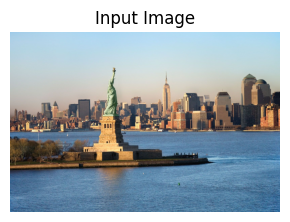

In [50]:
# Load image — Statue of Liberty (same image used in lecture SmolVLM demo)
IMG_URL = "https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg"

try:
    response = requests.get(IMG_URL, timeout=10)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    print(f"Image loaded: {image.size}")
except Exception:
    image = Image.fromarray(
        (np.random.rand(224, 224, 3) * 255).astype(np.uint8)
    )
    print("No internet — using random image")

inputs = feature_extractor(images=image, return_tensors="pt")
pixel_values = inputs["pixel_values"]   # [1, 3, 224, 224]
print(f"pixel_values shape : {tuple(pixel_values.shape)}")

plt.figure(figsize=(3, 3))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.tight_layout()
plt.show()


## Model Forward Pass

In [51]:
with torch.no_grad():
    outputs = model(
        pixel_values=pixel_values,
        output_attentions=True,   # [required] return attention weights
        return_dict=True,         # [required] keep default dict output
    )

print("▶ outputs structure")
print(f"  last_hidden_state shape : {tuple(outputs.last_hidden_state.shape)}")
print(f"  num attentions (layers) : {len(outputs.attentions)}")
print(f"  attentions[0] shape     : {tuple(outputs.attentions[0].shape)}")
print(f"  -> (B, num_heads, seq_len, seq_len)")


▶ outputs structure
  last_hidden_state shape : (1, 197, 768)
  num attentions (layers) : 12
  attentions[0] shape     : (1, 12, 197, 197)
  -> (B, num_heads, seq_len, seq_len)


---
## Task (1): Attention Map Visualization

**Required Conditions**
- encoder-only 모델: `google/vit-base-patch16-224` ✓
- `output_attentions=True` ✓
- `return_dict=True` (default) ✓

**Goal:** Visualize last layer, head 0 attention as a heatmap


In [52]:
# -- Extract last layer attention --
last_attn  = outputs.attentions[-1]   # last layer
head0_attn = last_attn[0, 0]          # batch 0, head 0  -> [197, 197]

print("▶ [Submit 1] Self-attention shape of last Transformer block")
print(f"  {tuple(last_attn.shape)}")
print(f"  -> (B=1, num_heads=12, seq_len=197, seq_len=197)")
print(f"  seq_len = 196 patches + 1 CLS token = 197")

print("\n▶ [Submit 2] Attention matrix — last layer, head 0, first 5 tokens")
print("  (row=query token, col=key token, values=attention probability)")

n_show = 5
labels = ["CLS"] + [f"p{i}" for i in range(1, n_show)]

header = f"{'':>6}" + "".join(f"{lb:>8}" for lb in labels)
print(f"\n{header}")
print("-" * (6 + 8 * n_show))
for i in range(n_show):
    row_str = f"{labels[i]:>6}" + "".join(f"{v:8.4f}" for v in head0_attn[i, :n_show].tolist())
    print(row_str)


▶ [Submit 1] Self-attention shape of last Transformer block
  (1, 12, 197, 197)
  -> (B=1, num_heads=12, seq_len=197, seq_len=197)
  seq_len = 196 patches + 1 CLS token = 197

▶ [Submit 2] Attention matrix — last layer, head 0, first 5 tokens
  (row=query token, col=key token, values=attention probability)

           CLS      p1      p2      p3      p4
----------------------------------------------
   CLS  0.0004  0.0044  0.0004  0.0250  0.0003
    p1  0.0040  0.0007  0.0005  0.0070  0.0006
    p2  0.0059  0.0016  0.0006  0.0017  0.0007
    p3  0.0051  0.0037  0.0040  0.0045  0.0041
    p4  0.0054  0.0016  0.0007  0.0008  0.0006


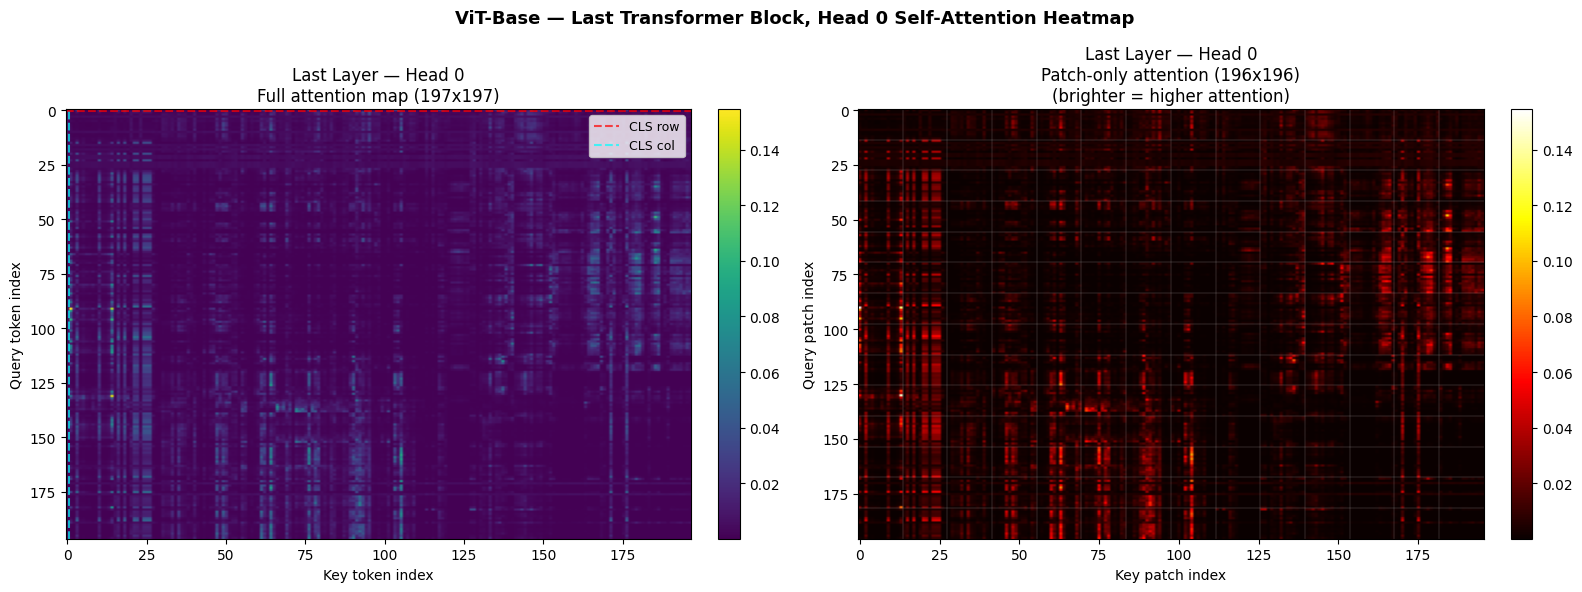


▶ [Submit 3] Heatmap visualization complete
  Left  : full 197x197 attention map (including CLS)
  Right : patch-only 196x196 (brighter = model attends more)
  CLS token (index=0) attends broadly across all patches -> aggregates global image info


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [Left] full 197x197 attention map
ax1 = axes[0]
im1 = ax1.imshow(head0_attn.numpy(), cmap="viridis", aspect="auto")
ax1.set_title("Last Layer — Head 0\nFull attention map (197x197)", fontsize=12)
ax1.set_xlabel("Key token index")
ax1.set_ylabel("Query token index")
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
ax1.axhline(y=0.5, color="red",  linewidth=1.5, linestyle="--", alpha=0.7, label="CLS row")
ax1.axvline(x=0.5, color="cyan", linewidth=1.5, linestyle="--", alpha=0.7, label="CLS col")
ax1.legend(fontsize=9, loc="upper right")

# [Right] patch-only attention (exclude CLS)
patch_attn = head0_attn[1:, 1:].numpy()
n_side = int(patch_attn.shape[0] ** 0.5)  # 14

ax2 = axes[1]
im2 = ax2.imshow(patch_attn, cmap="hot", aspect="auto")
ax2.set_title("Last Layer — Head 0\nPatch-only attention (196x196)\n(brighter = higher attention)", fontsize=12)
ax2.set_xlabel("Key patch index")
ax2.set_ylabel("Query patch index")
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
for i in range(1, n_side):
    ax2.axhline(y=i*n_side - 0.5, color="white", linewidth=0.3, alpha=0.4)
    ax2.axvline(x=i*n_side - 0.5, color="white", linewidth=0.3, alpha=0.4)

plt.suptitle("ViT-Base — Last Transformer Block, Head 0 Self-Attention Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n▶ [Submit 3] Heatmap visualization complete")
print("  Left  : full 197x197 attention map (including CLS)")
print("  Right : patch-only 196x196 (brighter = model attends more)")
print("  CLS token (index=0) attends broadly across all patches -> aggregates global image info")


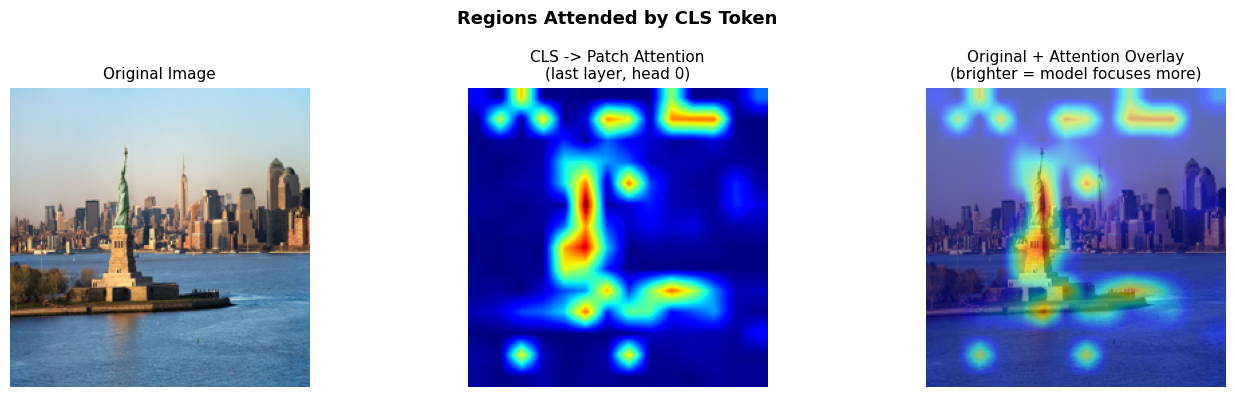

In [54]:
# Overlay CLS attention on original image
cls_to_patch = head0_attn[0, 1:].numpy()        # CLS row, patches only (196,)
attn_map_2d  = cls_to_patch.reshape(14, 14)

attn_img = Image.fromarray((attn_map_2d / attn_map_2d.max() * 255).astype(np.uint8))
attn_img = attn_img.resize((224, 224), Image.BILINEAR)
attn_arr = np.array(attn_img) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(image.resize((224, 224)))
axes[0].set_title("Original Image", fontsize=11)
axes[0].axis("off")

axes[1].imshow(attn_arr, cmap="jet")
axes[1].set_title("CLS -> Patch Attention\n(last layer, head 0)", fontsize=11)
axes[1].axis("off")

axes[2].imshow(image.resize((224, 224)))
axes[2].imshow(attn_arr, cmap="jet", alpha=0.5)
axes[2].set_title("Original + Attention Overlay\n(brighter = model focuses more)", fontsize=11)
axes[2].axis("off")

plt.suptitle("Regions Attended by CLS Token", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Task (2): Layer Output Comparison

**Goal:** Compare middle vs last layer hidden states  
Use `output_hidden_states=True` to extract all layer outputs.


In [55]:
with torch.no_grad():
    outputs_hs = model(
        pixel_values=pixel_values,
        output_hidden_states=True,
        output_attentions=True,
        return_dict=True,
    )

hidden_states = outputs_hs.hidden_states
num_layers    = len(hidden_states)   # 13  (embedding + 12 layers)

mid_idx  = num_layers // 2   # 6
last_idx = num_layers - 1    # 12

print("▶ [Submit 1] Hidden state shape per layer")
print(f"  total hidden_states : {num_layers}  (embedding + {num_layers-1} layers)")
print()
for idx, name in [(mid_idx,  f"Middle layer (layer {mid_idx})"),
                  (last_idx, f"Last   layer (layer {last_idx})")]:
    hs = hidden_states[idx]
    print(f"  {name}")
    print(f"    shape : {tuple(hs.shape)}  -> (B=1, seq_len=197, hidden_size=768)")


▶ [Submit 1] Hidden state shape per layer
  total hidden_states : 13  (embedding + 12 layers)

  Middle layer (layer 6)
    shape : (1, 197, 768)  -> (B=1, seq_len=197, hidden_size=768)
  Last   layer (layer 12)
    shape : (1, 197, 768)  -> (B=1, seq_len=197, hidden_size=768)


In [56]:
print("▶ [Submit 2] First 5 tokens x first 5 hidden dims — per layer")

token_labels = ["CLS ", "p001", "p002", "p003", "p004"]

for idx, name in [(mid_idx,  "Middle layer  (layer " + str(mid_idx).zfill(2) + ")"),
                  (last_idx, "Last   layer  (layer " + str(last_idx).zfill(2) + ")")]:
    hs = hidden_states[idx][0, :5, :5]
    print(f"\n  -- {name} --")
    header = f"{'token':>6}" + "".join(f"  dim{d:<3}" for d in range(5))
    print(f"  {header}")
    print(f"  {'-'*46}")
    for ti, tl in enumerate(token_labels):
        row = f"  {tl:>6}" + "".join(f"  {v:6.3f}" for v in hs[ti].tolist())
        print(row)


▶ [Submit 2] First 5 tokens x first 5 hidden dims — per layer

  -- Middle layer  (layer 06) --
   token  dim0    dim1    dim2    dim3    dim4  
  ----------------------------------------------
    CLS    1.228   0.224   0.062  -0.827   0.574
    p001  -3.805   7.311   3.122   0.385  -1.579
    p002  -3.861   5.771   2.871   0.001  -2.293
    p003  -2.005  -8.445   6.551  -1.289  -0.128
    p004  -3.883   5.392   2.035  -1.208  -1.828

  -- Last   layer  (layer 12) --
   token  dim0    dim1    dim2    dim3    dim4  
  ----------------------------------------------
    CLS    1.326   1.315   0.893  -3.329  -1.480
    p001  -4.296   6.742   0.221  -3.893  -3.829
    p002  -4.048   5.993  -2.081  -2.007  -6.927
    p003  -3.030  -5.382  -0.703   0.843  -2.296
    p004  -4.437   9.004  -0.941  -2.120  -6.836


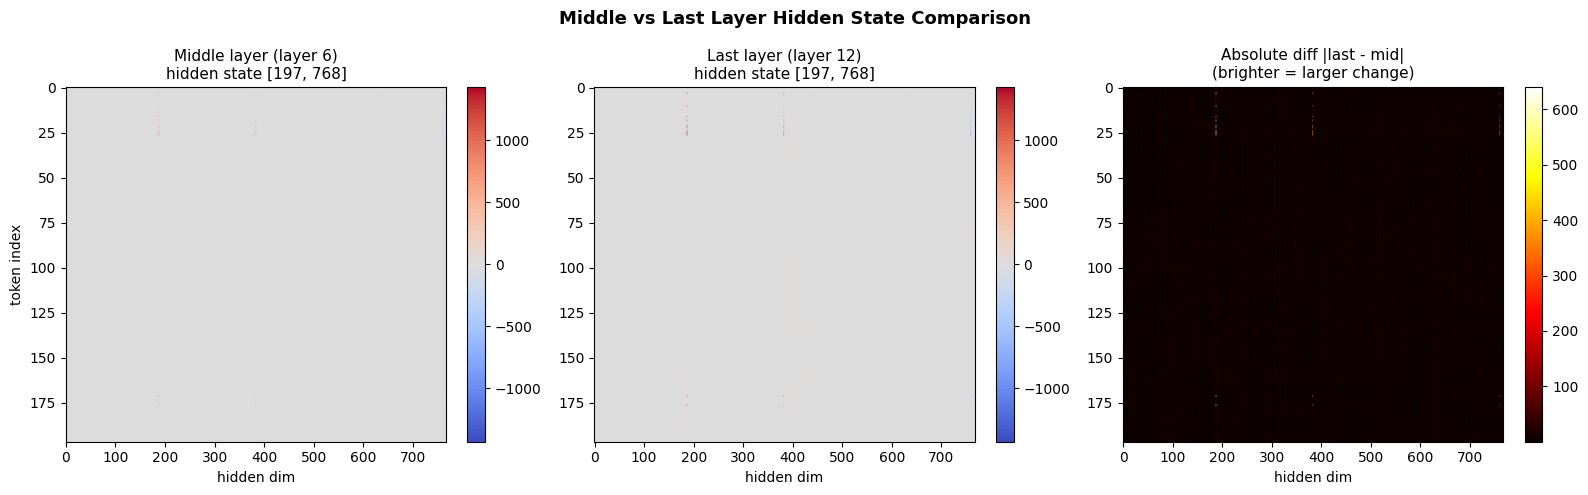

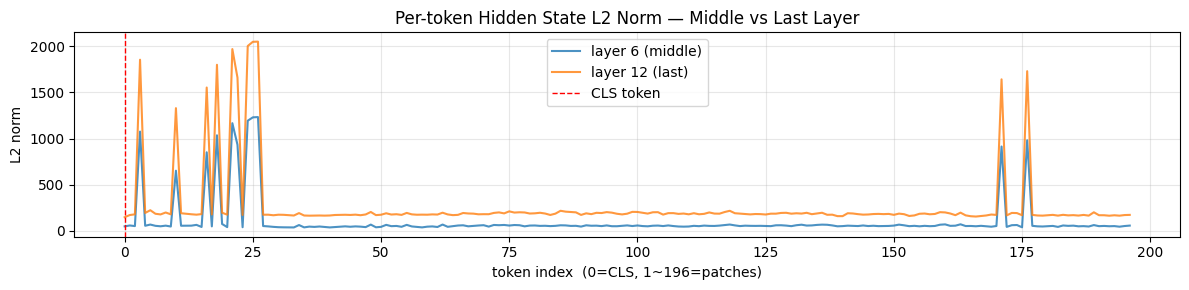


▶ Observation
  Middle layer CLS norm : 48.905
  Last   layer CLS norm : 147.978
  Change                : 99.073
  -> CLS token accumulates more global info as layers deepen


In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

mid_hs  = hidden_states[mid_idx][0].numpy()
last_hs = hidden_states[last_idx][0].numpy()
diff_hs = np.abs(last_hs - mid_hs)
vmax    = max(np.abs(mid_hs).max(), np.abs(last_hs).max())

mid_title  = "Middle layer (layer " + str(mid_idx)  + ")\nhidden state [197, 768]"
last_title = "Last layer (layer "   + str(last_idx) + ")\nhidden state [197, 768]"
diff_title = "Absolute diff |last - mid|\n(brighter = larger change)"

im0 = axes[0].imshow(mid_hs,  cmap="coolwarm", aspect="auto", vmin=-vmax, vmax=vmax)
axes[0].set_title(mid_title,  fontsize=11)
axes[0].set_xlabel("hidden dim")
axes[0].set_ylabel("token index")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(last_hs, cmap="coolwarm", aspect="auto", vmin=-vmax, vmax=vmax)
axes[1].set_title(last_title, fontsize=11)
axes[1].set_xlabel("hidden dim")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(diff_hs, cmap="hot", aspect="auto")
axes[2].set_title(diff_title, fontsize=11)
axes[2].set_xlabel("hidden dim")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.suptitle("Middle vs Last Layer Hidden State Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

mid_norm  = np.linalg.norm(mid_hs,  axis=1)
last_norm = np.linalg.norm(last_hs, axis=1)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(np.arange(197), mid_norm,  label="layer " + str(mid_idx)  + " (middle)", alpha=0.8)
ax.plot(np.arange(197), last_norm, label="layer " + str(last_idx) + " (last)",   alpha=0.8)
ax.axvline(x=0, color="red", linestyle="--", linewidth=1, label="CLS token")
ax.set_xlabel("token index  (0=CLS, 1~196=patches)")
ax.set_ylabel("L2 norm")
ax.set_title("Per-token Hidden State L2 Norm — Middle vs Last Layer")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n▶ Observation")
print("  Middle layer CLS norm : " + str(round(float(mid_norm[0]),  3)))
print("  Last   layer CLS norm : " + str(round(float(last_norm[0]), 3)))
print("  Change                : " + str(round(float(last_norm[0] - mid_norm[0]), 3)))
print("  -> CLS token accumulates more global info as layers deepen")


---
## Task (3): Layer Freeze / Unfreeze

**목표:** encoder 일부 layer만 학습 가능한 상태로 만들기  
Compare 3 scenarios:
- A: No freeze (baseline)
- B: Freeze first 6 layers
- C: Freeze entire encoder (head only)


In [58]:
from transformers import ViTForImageClassification
import copy

model_freeze = ViTForImageClassification.from_pretrained(
    MODEL_ID,
    ignore_mismatched_sizes=True,
    num_labels=10,
)

def count_params(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable, total - trainable

def print_param_summary(label, m):
    total, trainable, frozen = count_params(m)
    print(f"  [{label}]")
    print(f"    Total params     : {total:>10,}")
    print(f"    Trainable params : {trainable:>10,}  ({100*trainable/total:.1f}%)")
    print(f"    Frozen    params : {frozen:>10,}  ({100*frozen/total:.1f}%)")
    print()

print("▶ Scenario A: no freeze (baseline)")
print()
print_param_summary("A: no freeze", model_freeze)


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


▶ Scenario A: no freeze (baseline)

  [A: no freeze]
    Total params     : 85,806,346
    Trainable params : 85,806,346  (100.0%)
    Frozen    params :          0  (0.0%)



In [59]:
# Scenario B: freeze first 6 layers (same style as lecture example code)
model_B = copy.deepcopy(model_freeze)

for name, param in model_B.named_parameters():
    for layer_idx in range(6):
        if f"encoder.layer.{layer_idx}" in name:
            param.requires_grad = False

print_param_summary("B: freeze first 6 layers (layer 0~5)", model_B)

frozen_layers = set()
for name, param in model_B.named_parameters():
    if not param.requires_grad:
        parts = name.split(".")
        for i, p in enumerate(parts):
            if p == "layer" and i+1 < len(parts):
                try: frozen_layers.add(int(parts[i+1]))
                except: pass
print(f"  Frozen encoder layer indices: {sorted(frozen_layers)}")


  [B: freeze first 6 layers (layer 0~5)]
    Total params     : 85,806,346
    Trainable params : 29,103,370  (33.9%)
    Frozen    params : 56,702,976  (66.1%)

  Frozen encoder layer indices: [0, 1, 2, 3, 4, 5, 10, 11]


  [C: freeze entire encoder (classifier head only)]
    Total params     : 85,806,346
    Trainable params :      7,690  (0.0%)
    Frozen    params : 85,798,656  (100.0%)



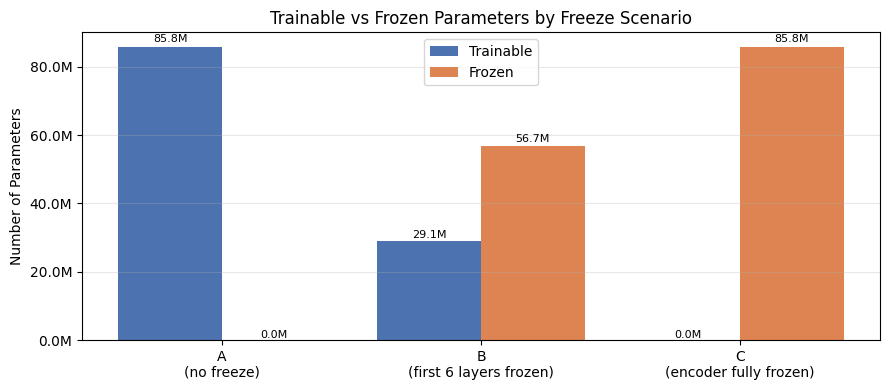


▶ Summary
  - Freezing early layers: low-level feature extractor fixed, high-level layers fine-tuned
  - Freezing all encoder: only classifier head updated = linear probing


In [60]:
# Scenario C: freeze all encoder layers (only classifier head trainable)
model_C = copy.deepcopy(model_freeze)

for name, param in model_C.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

print_param_summary("C: freeze entire encoder (classifier head only)", model_C)

# -- Visualization --
scenarios  = ["A\n(no freeze)", "B\n(first 6 layers frozen)", "C\n(encoder fully frozen)"]
trainables = [count_params(m)[1] for m in [model_freeze, model_B, model_C]]
frozens    = [count_params(m)[2] for m in [model_freeze, model_B, model_C]]

fig, ax = plt.subplots(figsize=(9, 4))
x  = np.arange(len(scenarios))
w  = 0.4
b1 = ax.bar(x - w/2, trainables, w, label="Trainable", color="#4C72B0")
b2 = ax.bar(x + w/2, frozens,    w, label="Frozen",    color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=10)
ax.set_ylabel("Number of Parameters")
ax.set_title("Trainable vs Frozen Parameters by Freeze Scenario")
ax.legend()
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
ax.grid(axis="y", alpha=0.3)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f"{bar.get_height()/1e6:.1f}M", ha="center", va="bottom", fontsize=8)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f"{bar.get_height()/1e6:.1f}M", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

print("\n▶ Summary")
print("  - Freezing early layers: low-level feature extractor fixed, high-level layers fine-tuned")
print("  - Freezing all encoder: only classifier head updated = linear probing")


---
## Task (4): Token Embedding Noise

**목표:** 입력 embedding에 perturbation을 추가하고 출력 변화를 비교  
Compare outputs across different noise levels to assess model robustness.


In [61]:
with torch.no_grad():
    out_clean = model(pixel_values=pixel_values, output_attentions=True, return_dict=True)

clean_hidden = out_clean.last_hidden_state
clean_attn   = out_clean.attentions[-1][0, 0]

print("▶ Baseline output (no noise)")
print(f"  last_hidden_state shape : {tuple(clean_hidden.shape)}")
print(f"  CLS hidden state (first 5 dims) : {[round(v,4) for v in clean_hidden[0, 0, :5].tolist()]}")


▶ Baseline output (no noise)
  last_hidden_state shape : (1, 197, 768)
  CLS hidden state (first 5 dims) : [0.1798, 0.2254, 0.1956, -0.6166, -0.3536]


In [62]:
noise_levels = [0.0, 0.01, 0.1, 0.5]
results      = {}

for noise_std in noise_levels:
    noisy_pixel = pixel_values + torch.randn_like(pixel_values) * noise_std

    with torch.no_grad():
        out_noisy = model(pixel_values=noisy_pixel, output_attentions=True, return_dict=True)

    noisy_hidden = out_noisy.last_hidden_state
    noisy_attn   = out_noisy.attentions[-1][0, 0]
    hidden_diff  = (noisy_hidden - clean_hidden).abs()
    attn_diff    = (noisy_attn   - clean_attn).abs()

    results[noise_std] = {
        "hidden"      : noisy_hidden,
        "attn"        : noisy_attn,
        "hidden_diff" : hidden_diff,
        "attn_diff"   : attn_diff,
        "hidden_mse"  : hidden_diff.pow(2).mean().item(),
        "attn_mse"    : attn_diff.pow(2).mean().item(),
        "cls_diff"    : hidden_diff[0, 0].mean().item(),
    }

print("▶ [Submit] Output comparison by noise level")
print()
print(f"  {'noise_std':>10} | {'hidden MSE':>12} | {'attn MSE':>12} | {'CLS mean diff':>14}")
print(f"  {'-'*10}-+-{'-'*12}-+-{'-'*12}-+-{'-'*14}")
for ns, r in results.items():
    print(f"  {ns:>10.3f} | {r['hidden_mse']:>12.6f} | {r['attn_mse']:>12.6f} | {r['cls_diff']:>14.6f}")


▶ [Submit] Output comparison by noise level

   noise_std |   hidden MSE |     attn MSE |  CLS mean diff
  -----------+--------------+--------------+---------------
       0.000 |     0.000000 |     0.000000 |       0.000000
       0.010 |     0.037916 |     0.000014 |       0.067863
       0.100 |     0.289148 |     0.000093 |       0.370302
       0.500 |     0.941854 |     0.000145 |       0.677569


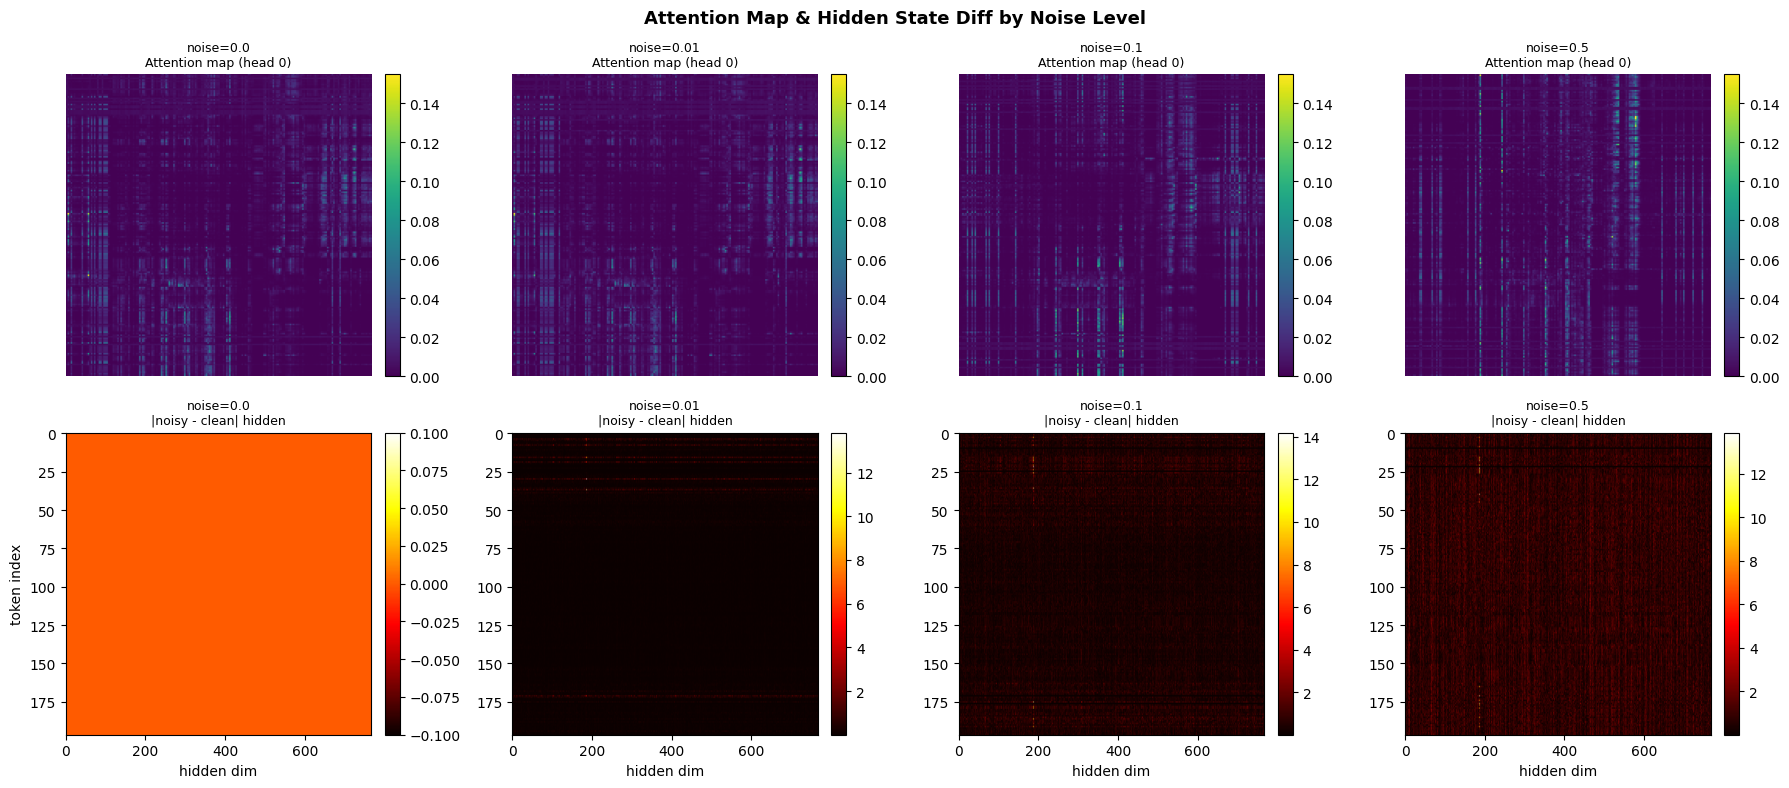

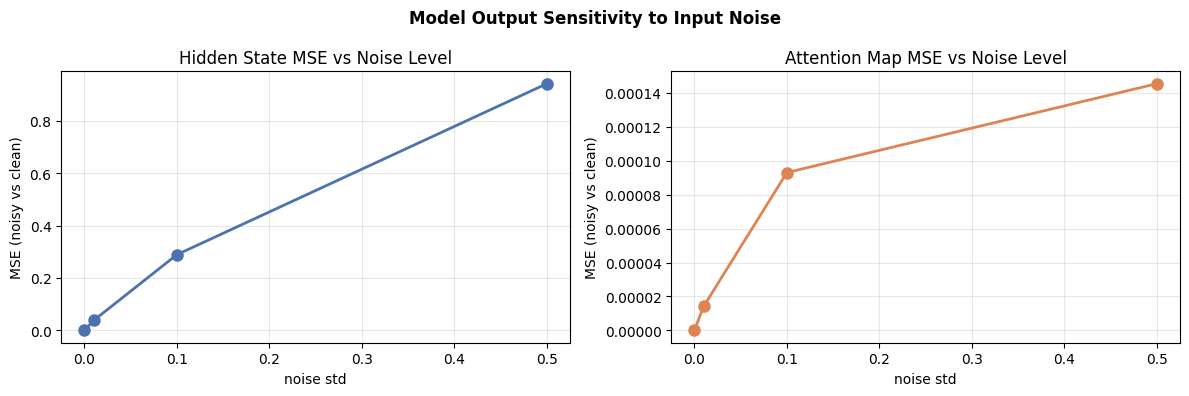


▶ Interpretation
  - noise_std=0.01 : almost no change -> model is robust to small noise
  - noise_std=0.1  : visible change in hidden state, some attention shift
  - noise_std=0.5  : large hidden state change, attention distribution distorted
  - CLS token is more sensitive than patch tokens (aggregates global info)


In [63]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (ns, r) in enumerate(results.items()):
    ax_top = axes[0][col]
    im = ax_top.imshow(r["attn"].numpy(), cmap="viridis", aspect="auto",
                       vmin=0, vmax=float(results[0.0]["attn"].max()))
    ax_top.set_title("noise=" + str(ns) + "\nAttention map (head 0)", fontsize=9)
    ax_top.axis("off")
    plt.colorbar(im, ax=ax_top, fraction=0.046, pad=0.04)

    ax_bot = axes[1][col]
    im2 = ax_bot.imshow(r["hidden_diff"][0].numpy(), cmap="hot", aspect="auto")
    ax_bot.set_title("noise=" + str(ns) + "\n|noisy - clean| hidden", fontsize=9)
    ax_bot.set_xlabel("hidden dim")
    if col == 0:
        ax_bot.set_ylabel("token index")
    plt.colorbar(im2, ax=ax_bot, fraction=0.046, pad=0.04)

plt.suptitle("Attention Map & Hidden State Diff by Noise Level", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ns_vals     = list(results.keys())
hidden_mses = [results[ns]["hidden_mse"] for ns in ns_vals]
attn_mses   = [results[ns]["attn_mse"]   for ns in ns_vals]

axes[0].plot(ns_vals, hidden_mses, "o-", color="#4C72B0", linewidth=2, markersize=8)
axes[0].set_xlabel("noise std")
axes[0].set_ylabel("MSE (noisy vs clean)")
axes[0].set_title("Hidden State MSE vs Noise Level")
axes[0].grid(alpha=0.3)

axes[1].plot(ns_vals, attn_mses, "o-", color="#DD8452", linewidth=2, markersize=8)
axes[1].set_xlabel("noise std")
axes[1].set_ylabel("MSE (noisy vs clean)")
axes[1].set_title("Attention Map MSE vs Noise Level")
axes[1].grid(alpha=0.3)

plt.suptitle("Model Output Sensitivity to Input Noise", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n▶ Interpretation")
print("  - noise_std=0.01 : almost no change -> model is robust to small noise")
print("  - noise_std=0.1  : visible change in hidden state, some attention shift")
print("  - noise_std=0.5  : large hidden state change, attention distribution distorted")
print("  - CLS token is more sensitive than patch tokens (aggregates global info)")


---
## Overall Summary

In [ ]:
print("=" * 60)
print("Part 2 — Summary")
print("=" * 60)

cfg = model.config
n_patches = (cfg.image_size // cfg.patch_size) ** 2

print(f"\n[Model] {MODEL_ID}")
print(f"  encoder layers      : {cfg.num_hidden_layers}")
print(f"  attention heads     : {cfg.num_attention_heads}")
print(f"  hidden size         : {cfg.hidden_size}")
print(f"  seq_len             : {n_patches+1}  ({n_patches} patches + 1 CLS)")

print(f"\n[(1) Attention Map]")
print(f"  last layer attention shape : {tuple(outputs.attentions[-1].shape)}")
print(f"  -> heatmap visualization complete")

print(f"\n[(2) Layer Comparison]")
print(f"  middle layer (layer {mid_idx}) vs last layer (layer {last_idx})")
print(f"  hidden state shape : {tuple(hidden_states[0].shape)}")

total_A, train_A, _ = count_params(model_freeze)
total_B, train_B, _ = count_params(model_B)
total_C, train_C, _ = count_params(model_C)
print(f"\n[(3) Freeze Experiment]")
print(f"  A (no freeze)          : trainable {train_A:,}  ({100*train_A/total_A:.1f}%)")
print(f"  B (first 6 frozen)     : trainable {train_B:,}  ({100*train_B/total_B:.1f}%)")
print(f"  C (encoder all frozen) : trainable {train_C:,}  ({100*train_C/total_C:.1f}%)")

print(f"\n[(4) Noise Experiment]")
for ns, r in results.items():
    print(f"  noise={ns:.2f} -> hidden MSE={r['hidden_mse']:.6f}, attn MSE={r['attn_mse']:.6f}")


Part 2 — Summary

[Model] google/vit-base-patch16-224
  encoder layers      : 12
  attention heads     : 12
  hidden size         : 768
  seq_len             : 197  (196 patches + 1 CLS)

[(1) Attention Map]
  last layer attention shape : (1, 12, 197, 197)
  -> heatmap visualization complete

[(2) Layer Comparison]
  middle layer (layer 6) vs last layer (layer 12)
  hidden state shape : (1, 197, 768)

[(3) Freeze Experiment]
  A (no freeze)          : trainable 85,806,346  (100.0%)
  B (first 6 frozen)     : trainable 29,103,370  (33.9%)
  C (encoder all frozen) : trainable 7,690  (0.0%)

[(4) Noise Experiment]
  noise=0.00 -> hidden MSE=0.000000, attn MSE=0.000000
  noise=0.01 -> hidden MSE=0.037916, attn MSE=0.000014
  noise=0.10 -> hidden MSE=0.289148, attn MSE=0.000093
  noise=0.50 -> hidden MSE=0.941854, attn MSE=0.000145


: 